# Plotting function used with the functional name dataset

In [1]:
import warnings

import pandas as pd
from h5py.h5z import FLAG_SKIP_EDC
import numpy as np
import math
import matplotlib.pyplot as plt

from pandas.io.sas.sas_constants import sas_date_formats

# from Scaling_data import column_names
from utils import *
from refined_functions import *


In [2]:
# df_1_hME1_scaled = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1_functional_names_diff_scaled_phPlus.xlsx")
# df_1_hME1_scaled = df_1_hME1_scaled.fillna(0)

# df_2_hME1_scaled = pd.read_csv("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_functional_names_diff_scaled_phPlus_clustered.tsv", sep = "\t")
df_2_hME1_scaled = pd.read_csv("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_functional_names_diff_scaled_phPlus_new_naming.tsv", sep = "\t")

df_2_hME1_scaled = df_2_hME1_scaled.fillna(0)

df_1_HEK_scaled = pd.read_csv("Experiment/1_HEK293T/Data/Processed/Full_dataset_HEK293T_functional_names_diff_scaled_phPlus.tsv", sep = "\t")
df_1_HEK_scaled = df_1_HEK_scaled.fillna(0)

## Filtering

In [25]:
# filtered_df = df_2_hME1_scaled.copy()
#
# data_type = "log2_FC"
# exclude_full = False
# condition_for_clustering = []
# column_names = filtered_df.columns.tolist()
# if len(condition_for_clustering) == 0:
#     column_selection = [element for element in column_names if element.startswith(f"{data_type}")] #f"{data_type}" in element]
#     if exclude_full == True:
#         column_selection = [element for element in column_names if element.startswith(f"{data_type}") and "full" not in element]
# else:
#     column_selection = [element for element in column_names if element.startswith(f"{data_type}") and any(cond in element for cond in condition_for_clustering)]
#     if exclude_full == True:
#         column_selection = [element for element in column_names if element.startswith(f"{data_type}") and any(cond in element for cond in condition_for_clustering) and "full" not in element]
#
#
# mask = filtered_df[column_selection].abs().max(axis=1) > 0.5
# filtered_df = filtered_df.loc[mask].copy()
# print(f"len(subdata_fc) [FC >0.5] = {len(filtered_df)}")

len(subdata_fc) [FC >0.5] = 0


In [3]:
df_filtered = filter_dynamics_extremes_refined(df = df_2_hME1_scaled,
                                       data_type="log2:FC",
                                       threshold=0.2,
                                       exclude_full = False,
                                       conditions = ["_EGF_", "_INS_", "_EGFnINS_"],
                                       cell_lines = ["WT"],)
print(df_filtered.shape)

(27713, 481)


## plot_protein_phosphosites_refined

In [4]:
def plot_protein_phosphosites_refined(df,
                                      data_type=str,
                                      proteins=list,
                                      cell_lines=[],
                                      conditions=[],
                                      legend_plot = list,
                                      color_palette={"_EGF_": "red",
                                                     "_INS_": "blue",
                                                     "_EGFnINS_": "fuchsia"},
                                      saving_path=str,
                                      saving_info="",
                                      title_info="",
                                      fit_y_lims=False,
                                      plot_close=False,
                                      save_pdf=False,
                                      save_png=False,
                                      # replicates = False,
                                      # exclude_rep = list,
                                      plot_individually=False,
                                      ):
    '''Plot to PDF ALL phosphosites of a list of proteins. You can decide to plot the phosphosties of the protein
    together in one plot or to plot them separatly.'''

    # Load dataframe if a path was passed instead
    if isinstance(df, pd.DataFrame):
        pass
    elif isinstance(df, str):
        if df.endswith(".xlsx"):
            df = pd.read_excel(df)
        elif df.endswith(".tsv"):
            df = pd.read_csv(df, sep="\t")
        else:
            raise ValueError("Unsupported file format. Use .xlsx or .tsv")

    sub_dtp = data_type.split(":")  # e.g. ["log2", "FC"]

    # Check x_axis
    x_axis_previous = [element for element in df.columns if
                       f"{cell_lines[0]}_{data_type}{conditions[0]}" in element]  # this could be any set of columns that have the time points
    x_axis = [s.split("_")[3] for s in x_axis_previous]
    len_x = len(x_axis)

    for protein in proteins:
        # Create sub-dataframe with only the protein we are interested in. If the protein doesn't exist in the dataframe skip code
        if protein in df['protein_name'].to_list():
            sub_df = df.loc[df['protein_name'] == protein].copy()
        elif protein in df['protein_Id'].to_list():
            sub_df = df.loc[df['protein_Id'] == protein].copy()
        else:
            print(f"The protein {protein} is not present in the dataset")
            continue
        print(f"Ploting sites of protein {protein}")

        # Extract the protein name and protein uniprot code for the folder
        saving_folder = f"{sub_df['protein_name'].iloc[0]}_{sub_df['protein_Id'].iloc[0]}"

        # Create output folder if saving
        if (save_pdf or save_png) and saving_path:
            new_path = os.path.join(saving_path, saving_folder)
            os.makedirs(new_path, exist_ok=True)  # cleaner than manual check

        # Sort the pepetides of the dataframe for better interpretation of the figure generated
        sub_df.sort_values(by=['site'], inplace=True)

        # Determine the dimentional space for the subplot
        number_phos = len(sub_df)
        sqrt_n_p = int(np.ceil(np.sqrt(number_phos)))
        sqrt_n_p_X = sqrt_n_p

        if sqrt_n_p > 2:
            empty_plots = (sqrt_n_p * sqrt_n_p) - number_phos
            if empty_plots >= sqrt_n_p:
                sqrt_n_p_X = sqrt_n_p - 1

        # Identify value columns for y-limit calculation
        column_names = df.columns.tolist()

        # Build a lookup: columns_dir[cell][condition] -> {"plotting": [...], "sd": [...]}
        # columns_dir = {cell: {condition: {} for condition in conditions} for cell in cell_lines}
        column_selection = []

        for cell in cell_lines:
            for condition in conditions:
                # columns_dir[cell][condition]["y_lim"] = [col for col in column_names
                new_cols = [col for col in column_names
                            if col.startswith(cell)
                            and condition in col
                            and data_type == col.split("_")[1]
                            ]
                column_selection = column_selection + new_cols

        # Resolve y-axis limits up front
        if isinstance(fit_y_lims, list):
            y_lim_min, y_lim_max = fit_y_lims[0], fit_y_lims[1]
            y_limt_info = f"_y_axis_fixed_{y_lim_min}_{y_lim_max}"
            use_fixed_ylims = True
        elif fit_y_lims is False:
            sub_values_df = sub_df[column_selection] if column_selection else pd.DataFrame()
            if not sub_values_df.empty:
                y_lim_max = sub_values_df.max().max() * 1.1
                y_lim_min = sub_values_df.min().min()
                y_lim_min = y_lim_min + y_lim_min * 0.1 if y_lim_min < 0 else y_lim_min * 0.97
            else:
                y_lim_min, y_lim_max = None, None
            use_fixed_ylims = False
            y_limt_info = ""
        else:  # fit_y_lims is True -> per-row dynamic limits
            use_fixed_ylims = None  # signals "compute per row"
            y_limt_info = "y_axis_perrow"

        if plot_individually == True:
            for index, row in sub_df.iterrows():
                protein_name = row["protein_name"]
                site = row["site"]

                fig, axes = plt.subplots()
                plot_data_refined(ax=axes,
                                      row_df=row,
                                      data_type=data_type,
                                      colors=color_palette,
                                      # legend=legend_plot,
                                      cell_lines=cell_lines,
                                      conditions=conditions
                                      )

                if save_pdf == True:
                    out = os.path.join(saving_path, saving_folder,
                                   f"{saving_folder}_{data_type}_{saving_info}_{site}.pdf")
                    plt.savefig(out)
                    print(f"Saved PDF: {out}")
                if save_png == True:
                    print("Not implemented yet")
                if save_pdf == False and save_png == False:
                    print(f"{protein_name}_{site}_{saving_info} Plot not saved")


        else:
            # Build figure
            fig, axes = plt.subplots(sqrt_n_p, sqrt_n_p_X, figsize=(18, 13))
            fig.tight_layout(w_pad=1.75, h_pad=3)
            plt.subplots_adjust(top=0.94)

            # Normalise axes to always be a 2D array
            if number_phos == 1:
                axes = np.array([[axes]])
            else:
                axes = np.atleast_2d(axes)

            k = 0
            for i in range(sqrt_n_p):
                for j in range(sqrt_n_p_X):
                    if k >= number_phos:
                        fig.delaxes(axes[i, j])
                        continue

                    row = sub_df.iloc[k]

                    plot_data_refined(ax=axes[i, j],
                                      row_df=row,
                                      data_type=data_type,
                                      colors=color_palette,
                                      # legend=legend_plot,
                                      cell_lines=cell_lines,
                                      conditions=conditions
                                      )

                    # Apply y-limits
                    if use_fixed_ylims is None:  # per-row dynamic
                        row_vals = row[column_selection].dropna() if column_selection else pd.Series()
                        if not row_vals.empty:
                            rmin, rmax = row_vals.min(), row_vals.max()
                            pad_min = rmin + rmin * 0.1 if rmin < 0 else rmin * 0.9
                            axes[i, j].set_ylim(pad_min, rmax * 1.1)
                    elif use_fixed_ylims and y_lim_min is not None:
                        axes[i, j].set_ylim(y_lim_min, y_lim_max)
                    elif not use_fixed_ylims and y_lim_min is not None:
                        axes[i, j].set_ylim(y_lim_min, y_lim_max)

                    axes[i, j].set_xlim(-1, len_x)
                    k += 1

            fig.legend(labels=legend_plot, loc="upper right", ncol=len(legend_plot))
            fig.suptitle(f"{saving_folder} {cell_lines} {conditions} {title_info} ({date.today()})", weight='bold')
            fig.tight_layout()

            if save_pdf:
                out = os.path.join(saving_path, saving_folder,
                                   f"{saving_folder}_{data_type}_{saving_info}.pdf")
                plt.savefig(out)
                print(f"Saved PDF: {out}")
            if save_png:
                out = os.path.join(saving_path, saving_folder,
                                   f"{saving_folder}_{data_type}_{saving_info}.png")
                plt.savefig(out)
                print(f"Saved PNG: {out}")
            if not save_pdf and not save_png:
                print(f"{saving_folder}_{data_type}_{saving_info} — plot not saved")

            if plot_close:
                plt.close(fig)


Ploting sites of protein STAM2
STAM2_O75886_log2:FC_ — plot not saved


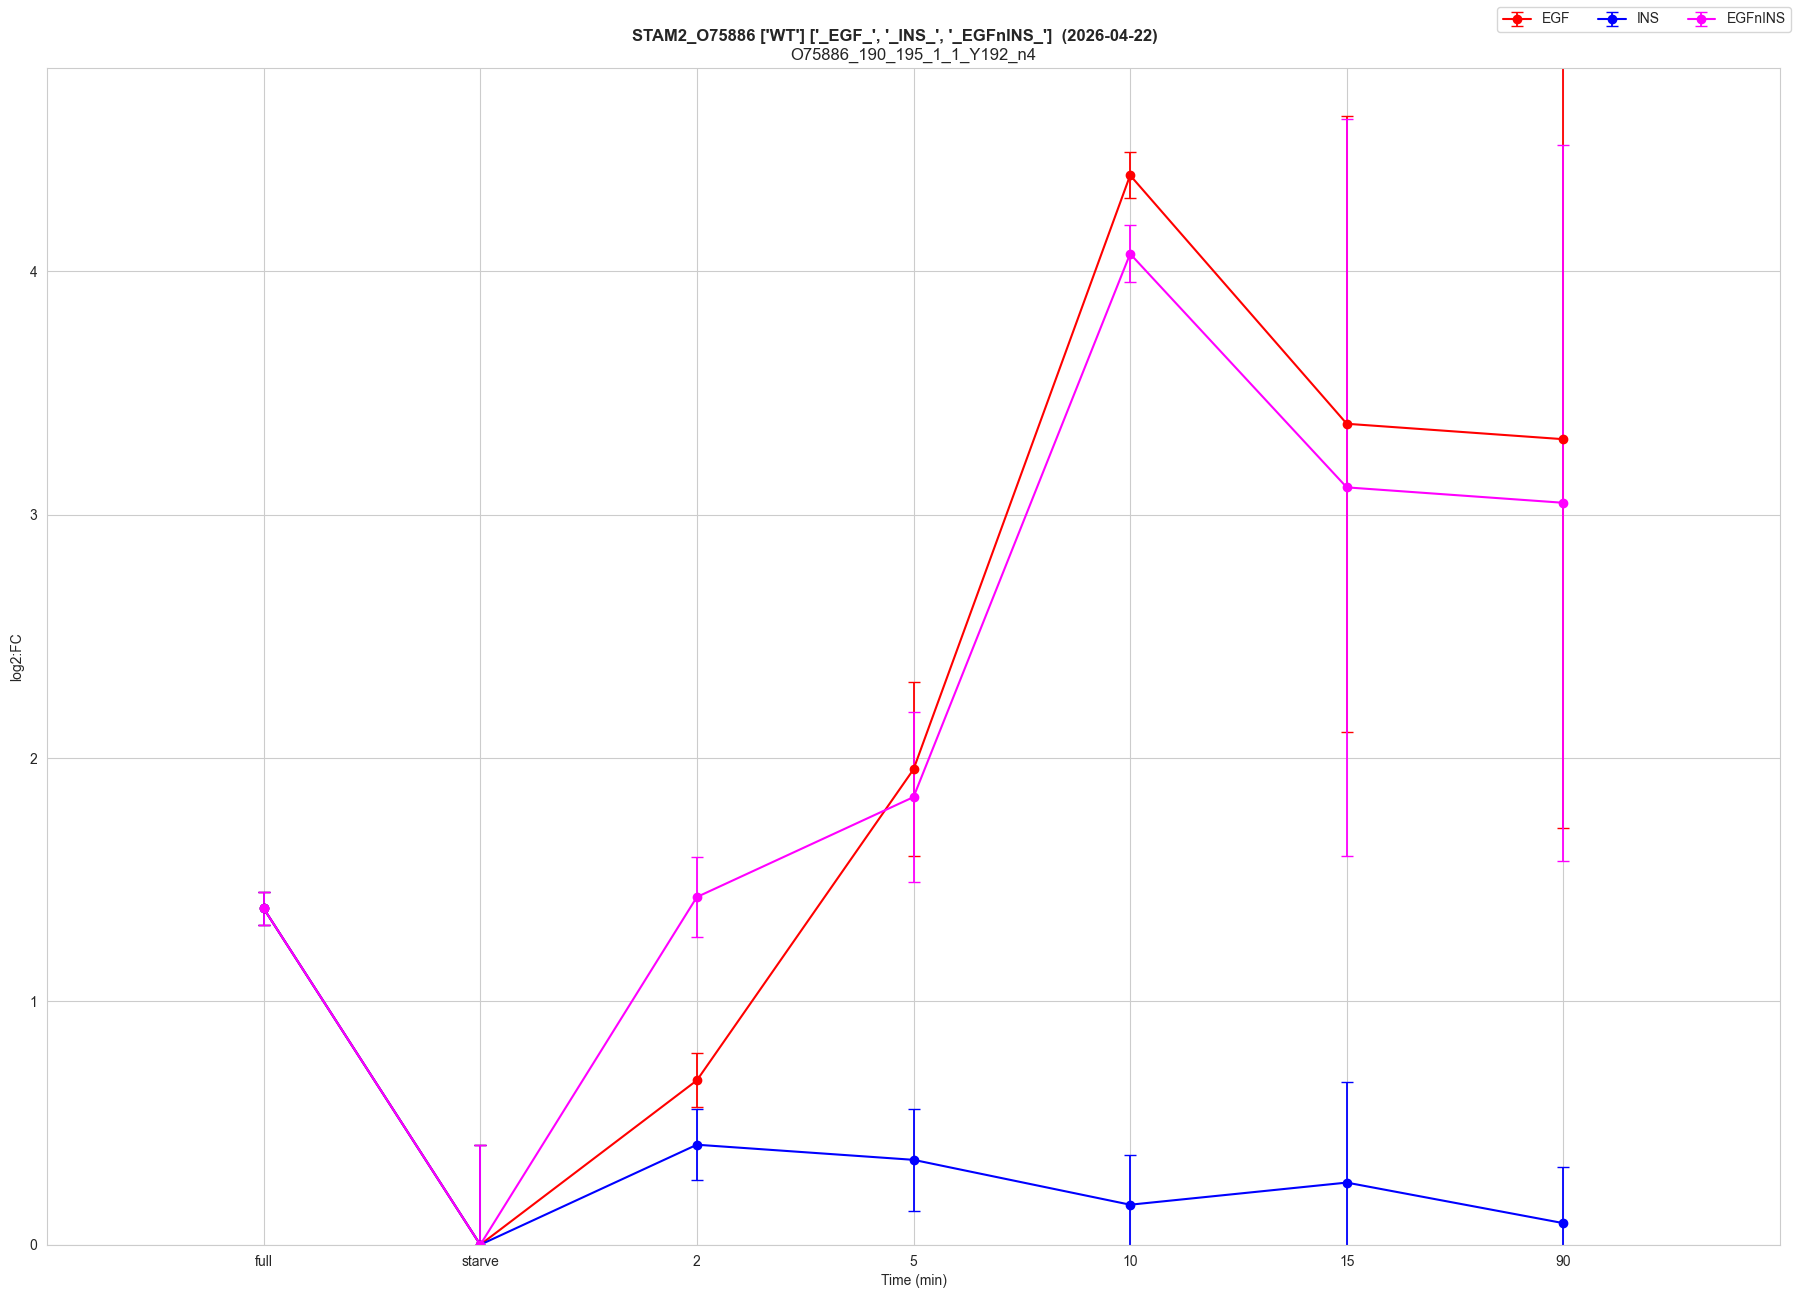

In [10]:
proteins= ["STAM2"] #TSC2

plot_protein_phosphosites_refined(df = df_filtered,
                                  proteins=proteins,
                                  data_type= "log2:FC",
                                  saving_path = "Experiment/Progress_report/Images/Protein_profile",
                                  legend_plot=["EGF", "INS", "EGFnINS"], #cannot take characters as _
                                  cell_lines = ["WT"],
                                  conditions = ["_EGF_", "_INS_", "_EGFnINS_"],
                                  color_palette = {"_EGF_": "red",
                                                    "_INS_": "blue",
                                                    "_EGFnINS_": "fuchsia"},
                                  fit_y_lims= False,
                                  save_pdf=False,
                                  saving_info="",
                                  plot_individually=False
                                  )


## plot_volcano_plot

In [ ]:

fig = plot_volcano_interactive_plotly_highlighting(
    df_2_hME1_scaled,
    fc_col="log2_FC_EGFnINS_5",
    pval_col="FC_pvalue_EGFnINS_5",
    site_col="site",  # or "found_phosphosites"
    highlight_proteins=["EGFR","SHC","SRC","GRB2","SOS1","GAB1","AKT1","PLCB3","IRS1"],  # mix of protein_Id/protein_name works
    match_cols=("protein_Id", "protein_name"),
    case_insensitive=True,
    show_highlight_labels=False,
    title=""
)
fig.show()

## Volcano plot with selected proteins highlight

In [ ]:
############## ["BRAF", "q15418" -ribosomal RPS6KA1, GAB1, P29590
### ["EGFR", "SOS1", "BRAF", "MAP2K1", 'KSR1', 'SHOC2', 'GAB1', 'PAK1', 'STAM', 'STAM2', 'RPS6KA3', 'AHNAK', 'AHNAK2']
protein_list = ["EGFR","SOS1","BRAF", "GAB1", "KRT13", "RPS6KA1"]
############ Single plot
# plot_volcano(df_2_hME1_scaled, "log2_FC_EGF_2", "FC_pvalue_EGF_2",
#              fc_thresh=1.0,
#              pval_thresh=0.05,
#              # title="log2_FC_EGF_10",
#              highlight_proteins=protein_list,
#              fit_x_limit = False)

############ In a 3×7 grid:
column_names = df_2_hME1_scaled.columns.to_list()
data_type1 = "log2_FC"
data_type2 = "FC_pvalue"
log2_FCs = [element for element in column_names if data_type1 in element]
FC_pvalues = [element for element in column_names if data_type2 in element]
pair_list = list(zip(log2_FCs, FC_pvalues))

# For only one subset if wanted (change the subplot size
# new_pair_list = pair_list[:7]
# # print(new_pair_list)
#
fig, axes = plt.subplots(3, 7, figsize=(30, 15)) #figsize=(18, 10)
axes = axes.flatten()
for i, (fc_col, pval_col) in enumerate(pair_list):  # pairs built as earlier
    plot_volcano(df_2_hME1_scaled, fc_col, pval_col,
                 highlight_proteins=protein_list,
                 ax=axes[i], title=fc_col,
                 fit_x_limit=True)
plt.tight_layout()
plt.show()

In [ ]:
erk_site = df_2_hME1_scaled[["protein_name", "protein_Id", "site", "ERK_motif", "functional_score"]].copy()

erk_site.loc[erk_site["protein_name"] == "ARAF"]

## Correlation plots

In [ ]:
df_2_hME1_scaled

In [ ]:
df_2_hME1_scaled.loc[df_2_hME1_scaled["protein_Id"] == "Q9NYT0"]

In [ ]:
fig = px.scatter(
        df_2_hME1_scaled,
        x=df_2_hME1_scaled.log2_FC_EGF_15,
        y=df_2_hME1_scaled.log2_FC_EGFnINS_15,
        hover_name=df_2_hME1_scaled["site"],
        # hover_data={fc_col: ':.3f', "neglog10p": ':.3f', pval_col: ':.3g'},
        # title=title or f"Volcano: {fc_col}",
        template="plotly_white"
)

# Threshold lines
# fig.add_hline(y=-np.log10(pval_thresh), line_dash="dash")
# fig.add_vline(x=fc_thresh, line_dash="dash")
# fig.add_vline(x=-fc_thresh, line_dash="dash")

fig.add_shape(
    type="line",
    x0=-5, y0=-5,
    x1=5, y1=5,  # normalized by default (if not using xref/yref)
    xref="x", yref="y",  # important: make it use data coordinates
    line=dict(color="red", dash="dash"),
)

fig.update_layout(
    xaxis_title="Log2_FC EGF 5 mins",
    yaxis_title="Log2_FC EGFnINS 5 mins",
    legend_title="",
    height=600,
    width=800,
)

In [ ]:
plot_volcano(df_2_hME1_scaled, fc_col, pval_col,
                 highlight_proteins=protein_list,
                 ax=axes[i], title=fc_col,
                 fit_x_limit=True)


## protein profile

In [ ]:
plot_protein_profile(df = filtered_df,
                         proteins = ["EGFR", "AKT1"],
                         data_type = "log2_FC",
                         saving_path="Experiment/Progress_report/Images/Individual_prot_profiles",
                         saving_info="_compact",
                         legend=False,
                         save_pdf=True,
                         save_png=False)

## protein profile fine line

In [ ]:
plot_protein_profiles_fine_line(df = filtered_df,
                                    proteins=["EGFR", "MAPK3", "BRAF", "RB1", "AKT1", "AKT2", "IRS2"],
                                    data_type= "log2_FC",
                                    saving_path="Experiment/Progress_report/Images/Individual_prot_profiles",
                                    legend=False,
                                    saving_info = "_fine_line",
                                    save_pdf=True,
                                    save_png=False)